In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from cart import DecisionTreeClassifier

In [2]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((112, 4), (38, 4))

In [3]:
tree = DecisionTreeClassifier(max_depth=4, min_samples_split=2)
tree.fit(X_train, y_train)

preds = tree.predict(X_test)
print("Predictions:", preds)
print("Actual:     ", y_test)
print(f"Test accuracy: {accuracy_score(y_test, preds):.3f}")

Predictions: [0 2 1 1 0 2 2 2 2 2 1 2 1 1 0 0 0 1 0 1 2 1 2 1 2 1 0 2 0 2 2 2 0 0 0 0 2
 1]
Actual:      [0 1 1 1 0 1 2 2 2 2 2 2 1 1 0 0 0 1 0 1 2 1 2 1 2 1 0 2 0 1 2 2 0 0 0 0 2
 1]
Test accuracy: 0.895


In [4]:
root = tree.root
print(f"root: feature #{root.feature_index} <= {root.threshold}")
print(f"      n_samples={root.n_samples}, gini={root.impurity:.3f}")

root: feature #2 <= 1.9
      n_samples=112, gini=0.667


In [5]:
def print_node(node, depth, branch=None, feature_names=None, class_names=None):
    prefix = '  ' * depth
    if branch is not None:
        prefix += f'{branch}: '

    if node.is_leaf:
        label = node.prediction
        if class_names is not None:
            label = class_names[label]
        print(f'{prefix}predicted class: {label} (n={node.n_samples}) gini={node.impurity:.3f}')
    else:
        feature = f'feature #{node.feature_index}'
        if feature_names is not None:
            feature = feature_names[node.feature_index]
        print(f'{prefix}[{feature} <= {node.threshold:.3g}] gini={node.impurity:.3f} n={node.n_samples}')


def viz(node, depth=0, branch=None, feature_names=None, class_names=None):
    print_node(node, depth, branch, feature_names, class_names)
    if not node.is_leaf:
        viz(node.left, depth + 1, 'True', feature_names, class_names)
        viz(node.right, depth + 1, 'False', feature_names, class_names)


iris = load_iris()
viz(root, feature_names=iris.feature_names, class_names=iris.target_names)

[petal length (cm) <= 1.9] gini=0.667 n=112
  True: predicted class: setosa (n=38) gini=0.000
  False: [petal length (cm) <= 4.8] gini=0.500 n=74
    True: [petal width (cm) <= 1.5] gini=0.056 n=35
      True: predicted class: versicolor (n=33) gini=0.000
      False: [sepal length (cm) <= 5.9] gini=0.500 n=2
        True: predicted class: versicolor (n=1) gini=0.000
        False: predicted class: virginica (n=1) gini=0.000
    False: [petal width (cm) <= 1.6] gini=0.142 n=39
      True: [petal length (cm) <= 4.9] gini=0.500 n=6
        True: predicted class: versicolor (n=2) gini=0.000
        False: predicted class: virginica (n=4) gini=0.375
      False: predicted class: virginica (n=33) gini=0.000


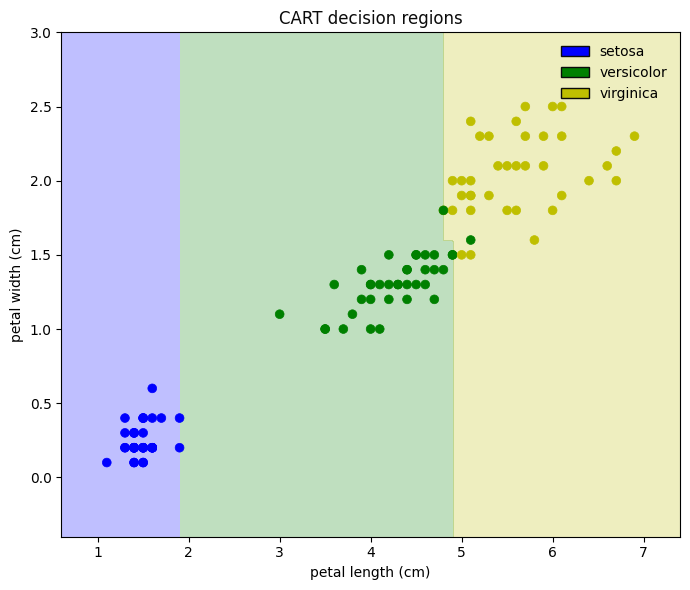

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CLASS_COLORS = ["b", "g", "y"]

feat_x, feat_y = 2, 3  # petal length, petal width
X2_train = X_train[:, [feat_x, feat_y]]

tree = DecisionTreeClassifier(max_depth=4, min_samples_split=2)
tree.fit(X2_train, y_train)

pad = 0.5
x_min, x_max = X2_train[:, 0].min() - pad, X2_train[:, 0].max() + pad
y_min, y_max = X2_train[:, 1].min() - pad, X2_train[:, 1].max() + pad
xv, yv = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = tree.predict(np.c_[xv.ravel(), yv.ravel()]).reshape(xv.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xv, yv, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=CLASS_COLORS, alpha=0.25)
ax.scatter(
    X2_train[:, 0], X2_train[:, 1],
    c=[CLASS_COLORS[c] for c in y_train],
    linewidth=0.5, s=40, zorder=3,
)

ax.set_xlabel(iris.feature_names[feat_x])
ax.set_ylabel(iris.feature_names[feat_y])
ax.set_title("CART decision regions", color="#0b0b0b")

legend_handles = [
    Patch(facecolor=CLASS_COLORS[i], edgecolor="#0b0b0b", label=name)
    for i, name in enumerate(iris.target_names)
]
ax.legend(handles=legend_handles, frameon=False)

plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
from cart import DecisionTreeRegressor

rng = np.random.default_rng(42)
X_reg = np.sort(rng.uniform(0, 10, 120)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + rng.normal(0, 0.15, X_reg.shape[0])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

reg_shallow = DecisionTreeRegressor(max_depth=2, min_samples_split=2)
reg_deep = DecisionTreeRegressor(max_depth=6, min_samples_split=2)
reg_shallow.fit(Xr_train, yr_train)
reg_deep.fit(Xr_train, yr_train)

for name, model in [("max_depth=2", reg_shallow), ("max_depth=6", reg_deep)]:
    preds = model.predict(Xr_test)
    mse = mean_squared_error(yr_test, preds)
    r2 = r2_score(yr_test, preds)
    print(f"{name}: MSE={mse:.3f}  R2={r2:.3f}")

max_depth=2: MSE=0.149  R2=0.709
max_depth=6: MSE=0.056  R2=0.891


In [8]:
viz(reg_shallow.root)

[feature #0 <= 2.72] gini=0.508 n=90
  True: [feature #0 <= 0.438] gini=0.090 n=23
    True: predicted class: 0.2633743449990637 (n=3) gini=0.018
    False: predicted class: 0.8500814337898804 (n=20) gini=0.056
  False: [feature #0 <= 5.79] gini=0.523 n=67
    True: predicted class: -0.6171693595446301 (n=28) gini=0.173
    False: predicted class: 0.5531562344319635 (n=39) gini=0.202


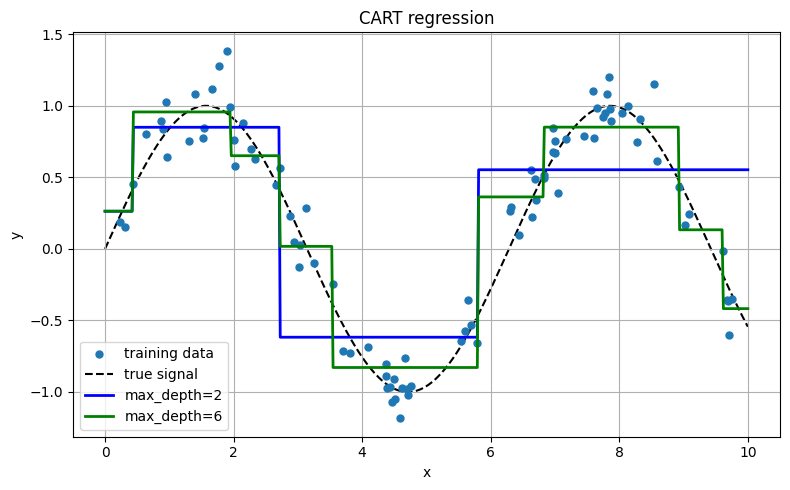

In [9]:
x_grid = np.linspace(0, 10, 500).reshape(-1, 1)
y_true = np.sin(x_grid).ravel()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    Xr_train, yr_train,
    s=25, zorder=2, label="training data",
)
ax.plot(x_grid, y_true, color="k", linestyle="--", linewidth=1.5, label="true signal", zorder=1)
ax.plot(x_grid, reg_shallow.predict(x_grid), color="b", linewidth=2, label="max_depth=2", zorder=3)
ax.plot(x_grid, reg_deep.predict(x_grid), color="g", linewidth=2, label="max_depth=6", zorder=3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("CART regression")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()